In [6]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import FancyArrowPatch
from IPython.display import clear_output
import time
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from project_specific_utils.dataloader import BrainAreas, load_img_natraster
from useful_stuff.general_utils.RSA import RSA
from useful_stuff.general_utils.utils import print_wise, TimeSeries
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
# from general_utils.dRSA import across_areas_dRSA
# from general_utils.II import InformationImbalance, compare_similarity_metrics

In [22]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'three0' #'baby1'#three0' #
    date: str =  "250313"  #'220226to527' #'250313' #  #
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    k=1
    metric_A = "cosine_cnt"
    metric_B = "euclidean"
    model_name: str = 'vit_l_16'
    layer_names= ['blocks.0.mlp.fc2', 'blocks.10.mlp.fc2', 'blocks.20.mlp.fc2']
    img_size: int = 384
    pooling: str = 'mean'
    pkg: str = 'timm'

cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
brain_areas = ['V1', 'V2', 'V3', 'PIT', 'CIT', 'AIT']

In [23]:
def draw_parallel_bidirectional_edge(ax, p0, p1, w01, w10,
                                     color="k", alpha=1.0, lw=2,
                                     arrow_scale=20,
                                     separation=0.05,
                                     node_radius=0.15,  
                                     margin=0.02, 
                                     wiggle=0.0):

    p0 = np.asarray(p0)
    p1 = np.asarray(p1)

    vec = p1 - p0
    total_length = np.linalg.norm(vec)
    direction = vec / total_length
    mid = (p0 + p1) / 2

    # usable length between circle borders
    usable_length = total_length - 2 * node_radius - 2 * margin
    usable_length = max(usable_length, 0)

    # perpendicular direction
    perp = np.array([-direction[1], direction[0]])

    # shift midpoint to be between circle borders
    center_segment_start = p0 + direction * (node_radius + margin)
    center_segment_end   = p1 - direction * (node_radius + margin)
    mid = (center_segment_start + center_segment_end) / 2

    # ---- A → B ----
    if w01 > 0:
        factor = np.clip(w01, 0.01, 1.0)
        half_len = factor * usable_length / 2

        start = mid - direction * half_len
        end   = mid + direction * half_len

        # offset = separation * perp
        offset = (separation + wiggle) * perp

        arrow = FancyArrowPatch(
            start + offset,
            end + offset,
            arrowstyle='-|>',
            mutation_scale=arrow_scale,
            linewidth=lw,
            color=color,
            alpha=alpha,
            zorder=2
        )
        ax.add_patch(arrow)

    # ---- B → A ----
    if w10 > 0:
        factor = np.clip(w10, 0.01, 1.0)
        half_len = factor * usable_length / 2

        start = mid + direction * half_len
        end   = mid - direction * half_len

        # offset = -separation * perp
        offset = -(separation + wiggle) * perp
        arrow = FancyArrowPatch(
            start + offset,
            end + offset,
            arrowstyle='-|>',
            mutation_scale=arrow_scale,
            linewidth=lw,
            color=color,
            alpha=alpha,
            zorder=2
        )
        ax.add_patch(arrow)


def get_label_color(color):
    """
    Returns 'white' if color is dark, 'black' if light.
    Accepts: color name (str), RGB tuple, or RGBA tuple
    """
    try:
        # convert string color names to RGB
        rgb = mcolors.to_rgb(color)
    except ValueError:
        # assume it's already a tuple/list
        rgb = color[:3]  # take first 3 values if RGBA

    r, g, b = rgb
    lum = 0.299*r + 0.587*g + 0.114*b
    return 'white' if lum < 0.5 else 'black'

def circular_with_center(G, center_node):
    # All nodes except the center
    other_nodes = [n for n in G.nodes if n != center_node]
    
    # Circular layout for the others
    pos = nx.circular_layout(other_nodes)
    
    # Put center node at origin
    pos[center_node] = np.array([0.0, 0.0])
    
    return pos

In [24]:
def draw_parallel_bidirectional_edge(ax, p0, p1, w01, w10,
                                     node_radius=0.2, margin=0.02,
                                     separation=0.05, wiggle=0.0,
                                     arrow_scale=15, lw=2, color="k",
                                     alpha=1.0, bg_value=0.5,
                                     bg_color="gray", bg_alpha=0.3):
    p0 = np.asarray(p0)
    p1 = np.asarray(p1)
    vec = p1 - p0
    total_length = np.linalg.norm(vec)
    if total_length == 0: return
    direction = vec / total_length
    center_segment_start = p0 + direction*(node_radius+margin)
    center_segment_end   = p1 - direction*(node_radius+margin)
    mid = (center_segment_start + center_segment_end)/2
    usable_length = total_length - 2*node_radius - 2*margin
    usable_length = max(usable_length,0)
    perp = np.array([-direction[1], direction[0]])

    # shading
    if bg_value is not None and usable_length>0:
        shade_len = bg_value*usable_length
        start_bg = mid - direction*(shade_len/2)
        end_bg = mid + direction*(shade_len/2)
        ax.plot([start_bg[0],end_bg[0]], [start_bg[1],end_bg[1]],
                color=bg_color, alpha=bg_alpha, lw=lw+20, zorder=1)

    # arrow A->B
    if w01>0:
        factor = np.clip(w01,0.01,1.0)
        half_len = factor*usable_length/2
        start = mid - direction*half_len
        end = mid + direction*half_len
        offset = (separation+wiggle)*perp
        arrow = FancyArrowPatch(start+offset, end+offset,
                                arrowstyle='-|>', mutation_scale=arrow_scale,
                                linewidth=lw, color=color, alpha=alpha, zorder=2)
        ax.add_patch(arrow)

    # arrow B->A
    if w10>0:
        factor = np.clip(w10,0.01,1.0)
        half_len = factor*usable_length/2
        start = mid + direction*half_len
        end = mid - direction*half_len
        offset = -(separation+wiggle)*perp
        arrow = FancyArrowPatch(start+offset, end+offset,
                                arrowstyle='-|>', mutation_scale=arrow_scale,
                                linewidth=lw, color=color, alpha=alpha, zorder=2)
        ax.add_patch(arrow)


In [25]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt



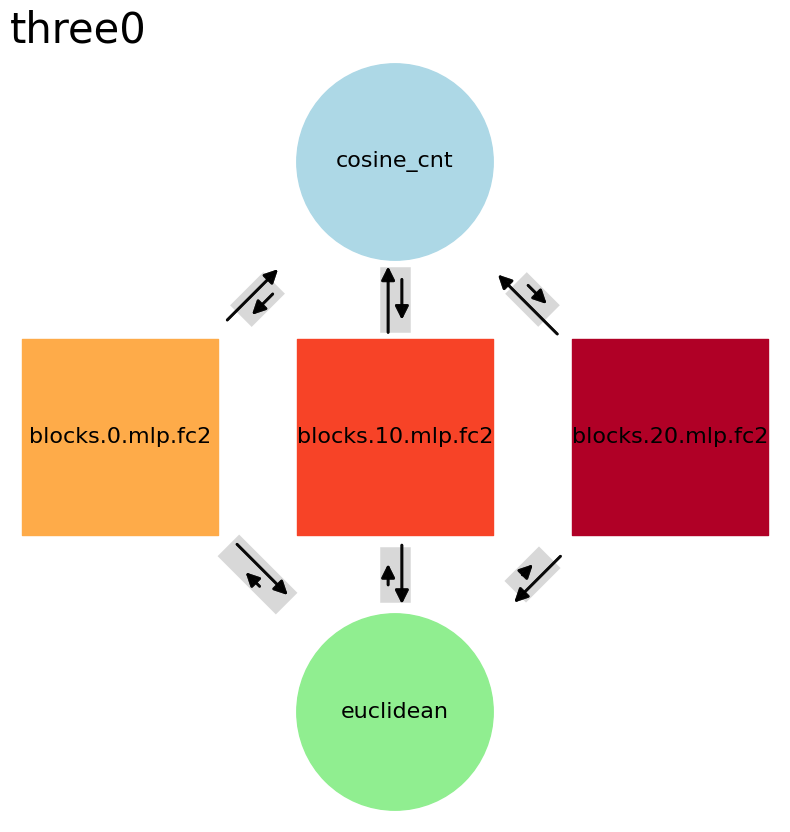

In [26]:
def yellow_red_gradient(n):
    cmap = plt.cm.YlOrRd  # Yellow → Orange → Red
    return [cmap(i) for i in np.linspace(0.4, .9, n)]

# Nodes
top_node = cfg.metric_A
bottom_node = cfg.metric_B
middle_nodes = cfg.layer_names
# Graph (DiGraph, edges just for bookkeeping)
G = nx.DiGraph()
G.add_node(top_node)
G.add_node(bottom_node)
G.add_nodes_from(middle_nodes)

# Example: similarity between nodes u and v
rsa_dict = {}
for mt in [cfg.metric_A, cfg.metric_B]:
    for l in cfg.layer_names:
        save_name_RSA = f"{paths['data_path']}/results/static_dRSA_{mt}-{mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        rsa_dict[(mt, l)] = np.max(np.load(save_name_RSA)["arr_0"])

edge_weights = {}
for mt in [cfg.metric_A, cfg.metric_B]:
    for l in cfg.layer_names:
        save_name_A2B = f"{paths['data_path']}/results/dynII_A2B_k{cfg.k}_{mt}-{mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        save_name_B2A = f"{paths['data_path']}/results/dynII_B2A_k{cfg.k}_{mt}-{mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        A2B = np.max(1 - np.load(save_name_A2B)["arr_0"])
        B2A = np.max(1 - np.load(save_name_B2A)["arr_0"])
        edge_weights[(mt, l)] = A2B
        edge_weights[(l, mt)] = B2A

pos = {
    top_node: (0, 2),
    middle_nodes[0]: (-2, 0),
    middle_nodes[1]: (0, 0),
    middle_nodes[2]: (2, 0),
    bottom_node: (0, -2),
}

fig, ax = plt.subplots(figsize=(8, 8))

# Circles
nx.draw_networkx_nodes(G, pos, nodelist=[top_node, bottom_node],
                       node_shape='o', node_size=20000, node_color=['lightblue', 'lightgreen'])

# Squares
colors = yellow_red_gradient(len(cfg.layer_names))
nx.draw_networkx_nodes(G, pos, nodelist=middle_nodes,
                       node_shape='s', node_size=20000, node_color=colors)

# Labels
nx.draw_networkx_labels(G, pos, font_size=16)
for u, v in edge_weights:
    w_uv = edge_weights.get((u, v), 0)
    w_vu = edge_weights.get((v, u), 0)

    bg_value = rsa_dict.get((u, v), 0)  # plug in precomputed metric

    draw_parallel_bidirectional_edge(
        ax,
        p0=pos[u],
        p1=pos[v],
        w01=w_uv,
        w10=w_vu,
        color="k",
        alpha=0.8,
        lw=2,
        arrow_scale=20,
        separation=0.05,
        node_radius=0.2,
        margin=0.02,
        wiggle=0.0,
        bg_value=bg_value,  # ← third metric from outside
        bg_color="gray",
        bg_alpha=0.3
    )
ax.set_aspect('equal')
ax.axis('off')
ax.margins(0.2)
plt.tight_layout()
plt.title(cfg.monkey_name, fontsize=30, loc='left')
plt.show()

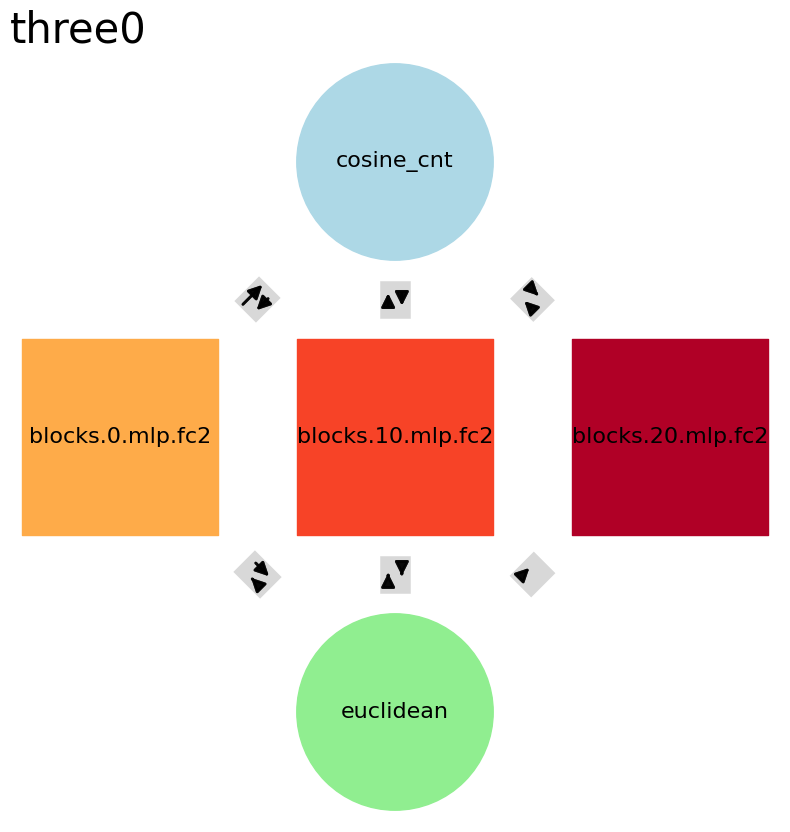

In [31]:
for i in range(30):
    def yellow_red_gradient(n):
        cmap = plt.cm.YlOrRd  # Yellow → Orange → Red
        return [cmap(i) for i in np.linspace(0.4, .9, n)]

    # Nodes
    top_node = cfg.metric_A
    bottom_node = cfg.metric_B
    middle_nodes = cfg.layer_names
    # Graph (DiGraph, edges just for bookkeeping)
    G = nx.DiGraph()
    G.add_node(top_node)
    G.add_node(bottom_node)
    G.add_nodes_from(middle_nodes)

    # Example: similarity between nodes u and v
    rsa_dict = {}
    for mt in [cfg.metric_A, cfg.metric_B]:
        for l in cfg.layer_names:
            save_name_RSA = f"{paths['data_path']}/results/static_dRSA_{mt}-{mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
            rsa_dict[(mt, l)] = np.load(save_name_RSA)["arr_0"][i]

    edge_weights = {}
    for mt in [cfg.metric_A, cfg.metric_B]:
        for l in cfg.layer_names:
            save_name_A2B = f"{paths['data_path']}/results/dynII_A2B_k{cfg.k}_{mt}-{mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
            save_name_B2A = f"{paths['data_path']}/results/dynII_B2A_k{cfg.k}_{mt}-{mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
            A2B = 1 - np.load(save_name_A2B)["arr_0"][i]
            B2A = 1 - np.load(save_name_B2A)["arr_0"][i]
            edge_weights[(mt, l)] = A2B
            edge_weights[(l, mt)] = B2A

    pos = {
        top_node: (0, 2),
        middle_nodes[0]: (-2, 0),
        middle_nodes[1]: (0, 0),
        middle_nodes[2]: (2, 0),
        bottom_node: (0, -2),
    }

    fig, ax = plt.subplots(figsize=(8, 8))

    # Circles
    nx.draw_networkx_nodes(G, pos, nodelist=[top_node, bottom_node],
                        node_shape='o', node_size=20000, node_color=['lightblue', 'lightgreen'])

    # Squares
    colors = yellow_red_gradient(len(cfg.layer_names))
    nx.draw_networkx_nodes(G, pos, nodelist=middle_nodes,
                        node_shape='s', node_size=20000, node_color=colors)

    # Labels
    nx.draw_networkx_labels(G, pos, font_size=16)
    for u, v in edge_weights:
        w_uv = edge_weights.get((u, v), 0)
        w_vu = edge_weights.get((v, u), 0)

        bg_value = rsa_dict.get((u, v), 0)  # plug in precomputed metric

        draw_parallel_bidirectional_edge(
            ax,
            p0=pos[u],
            p1=pos[v],
            w01=w_uv,
            w10=w_vu,
            color="k",
            alpha=0.8,
            lw=2,
            arrow_scale=20,
            separation=0.05,
            node_radius=0.2,
            margin=0.02,
            wiggle=0.0,
            bg_value=bg_value,  # ← third metric from outside
            bg_color="gray",
            bg_alpha=0.3
        )
    ax.set_aspect('equal')
    ax.axis('off')
    ax.margins(0.2)
    plt.tight_layout()
    plt.title(cfg.monkey_name, fontsize=30, loc='left')
    plt.show()
    clear_output(wait=True)
    time.sleep(.15)

In [29]:
plt.plot(tot_RSA_max, label="rsa")
plt.plot(tot_A2B_max, label="A2B")
plt.plot(tot_B2A_max, label="B2A")
plt.legend();
plt.title(f"RSA-II comparison - {cfg.monkey_name} {mt}", fontsize=15);
plt.xlabel("layer block", fontsize=15)
plt.ylabel("RSA or 1 - II", fontsize=15)

NameError: name 'tot_RSA_max' is not defined

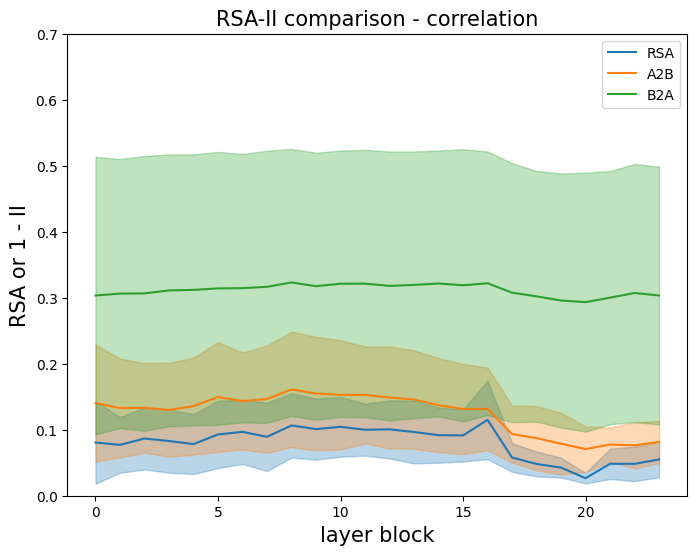

In [239]:
fig, ax = plt.subplots(1, figsize=(8, 6))
monkey_dates = zip(["paul", "baby1",  "three0", "red", "octavius", 'friday',  "baby1"], ["230204", '220226to527', '250313', '220227', '220227to405', '220228to327', '240816to26'])
mt = "correlation"
monk_rsa = []
monk_A2B = []
monk_B2A = []
counter = 0
rsa_color = "tab:blue"
A2B_color = "tab:orange"
B2A_color = "tab:green"

def get_onset_latency(curve, fs, threshold_fraction=0.10):
    arr = np.asarray(curve, dtype=float)
    peak = np.nanmax(arr)
    if not np.isfinite(peak) or peak <= 0:
        return np.nan
    crossing_idx = np.flatnonzero(arr >= peak * threshold_fraction)
    if crossing_idx.size == 0:
        return np.nan
    return crossing_idx[0] * 1000 / fs

for monkey_name, date in monkey_dates:
    counter +=1
    tot_RSA_max = []
    tot_RSA_lat = []
    tot_RSA_onset_lat = []
    tot_A2B_lat = []
    tot_A2B_onset_lat = []
    tot_A2B_max = []
    tot_B2A_max = []
    tot_B2A_lat = []
    tot_B2A_onset_lat = []
    for l in layers:
        save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{cfg.k}_{mt}-{mt}_{monkey_name}_{date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{cfg.k}_{mt}-{mt}_{monkey_name}_{date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        save_name_RSA = f"{paths['livingstone_lab']}/tiziano/results/static_dRSA_{mt}-{mt}_{monkey_name}_{date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        RSA = np.load(save_name_RSA)["arr_0"]
        RSA_lat = np.argmax(RSA) * 1000/cfg.new_fs
        RSA_onset_lat = get_onset_latency(RSA, cfg.new_fs, threshold_fraction=0.10)
        RSA_max = np.max(RSA)
        tot_RSA_max.append(RSA_max)
        tot_RSA_lat.append(RSA_lat)
        tot_RSA_onset_lat.append(RSA_onset_lat)
        A2B = 1 - np.load(save_name_A2B)["arr_0"]
        A2B_lat = np.argmax(A2B) * 1000/cfg.new_fs
        A2B_onset_lat = get_onset_latency(A2B, cfg.new_fs, threshold_fraction=0.10)
        A2B_max = np.max(A2B)
        tot_A2B_max.append(A2B_max)
        tot_A2B_lat.append(A2B_lat)
        tot_A2B_onset_lat.append(A2B_onset_lat)
        B2A = 1- np.load(save_name_B2A)["arr_0"]
        B2A_lat = np.argmax(B2A) * 1000/cfg.new_fs
        B2A_onset_lat = get_onset_latency(B2A, cfg.new_fs, threshold_fraction=0.10)
        B2A_max = np.max(B2A)
        tot_B2A_max.append(B2A_max)
        tot_B2A_lat.append(B2A_lat)
        tot_B2A_onset_lat.append(B2A_onset_lat)
    monk_rsa.append(tot_RSA_max)
    monk_A2B.append(tot_A2B_max)
    monk_B2A.append(tot_B2A_max)
    # ax[1].plot(tot_RSA_lat, color="tab:blue")
    # ax[1].plot(tot_A2B_lat, color="tab:orange")
    # ax[1].plot(tot_B2A_lat, color="tab:green")
    # plt.legend();
    # plt.title(f"RSA-II comparison - {cfg.monkey_name} {mt}", fontsize=15);
    # plt.xlabel("layer block", fontsize=15)
    # plt.ylabel("RSA or 1 - II", fontsize=15)
# ax.plot(monk_rsa/counter, linewidth=5, color = "tab:blue")
# ax.plot(monk_A2B/counter, linewidth=5, color = "tab:orange")
# ax.plot(monk_B2A/counter, linewidth=5, color = "tab:green")
ax.set_xlabel("layer block", fontsize=15)
ax.set_ylabel("RSA or 1 - II", fontsize=15)
ax.set_title(f"RSA-II comparison - {mt}", fontsize=15)
ax.set_ylim([0,.7])
rsa_final = np.stack(monk_rsa)
A2B_final = np.stack(monk_A2B)
B2A_final = np.stack(monk_B2A)
rsa_mean = np.mean(rsa_final, axis=0)
A2B_mean = np.mean(A2B_final, axis=0)
B2A_mean = np.mean(B2A_final, axis=0)
rsa_std = np.std(rsa_final, axis=0)
A2B_std = np.std(A2B_final, axis=0)
B2A_std = np.std(B2A_final, axis=0)
ax.plot(rsa_mean, color=rsa_color, label="RSA")
ax.plot(A2B_mean, color=A2B_color, label="A2B")
ax.plot(B2A_mean, color=B2A_color, label="B2A")
plt.fill_between(np.arange(len(layers)), rsa_mean - rsa_std, rsa_mean + rsa_std, color=rsa_color, alpha=0.3)
plt.fill_between(np.arange(len(layers)), A2B_mean - A2B_std, A2B_mean + A2B_std, color=A2B_color, alpha=0.3)
plt.fill_between(np.arange(len(layers)), B2A_mean - B2A_std, B2A_mean + B2A_std, color=B2A_color, alpha=0.3)
plt.legend()

In [229]:
np.stack(monk_rsa).shape

(7, 24)

Text(0, 0.5, 'Peak latency (ms)')

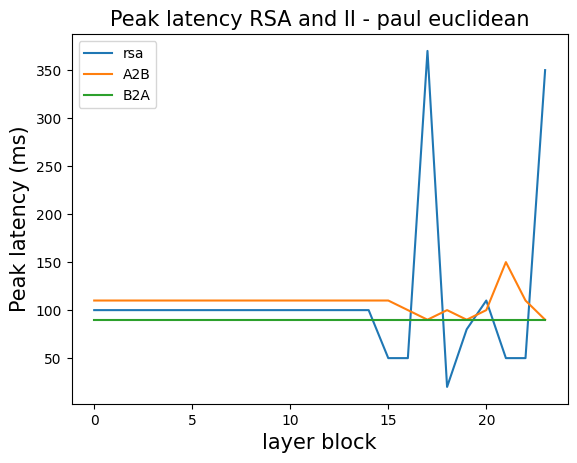

In [171]:
plt.plot(tot_RSA_lat, label="rsa")
plt.plot(tot_A2B_lat, label="A2B")
plt.plot(tot_B2A_lat, label="B2A")
plt.legend();
plt.title(f"Peak latency RSA and II - {cfg.monkey_name} {mt}", fontsize=15)
plt.xlabel("layer block", fontsize=15)
plt.ylabel("Peak latency (ms)", fontsize=15)

In [ ]:
plt.plot(tot_RSA_onset_lat, label="rsa")
plt.plot(tot_A2B_onset_lat, label="A2B")
plt.plot(tot_B2A_onset_lat, label="B2A")
plt.legend();
plt.title(f"Onset latency RSA and II - {cfg.monkey_name} {mt} | 10% peak", fontsize=15)
plt.xlabel("layer block", fontsize=15)
plt.ylabel("Onset latency (ms)", fontsize=15)
